In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import scipy.optimize as opt
import astropy.coordinates as coords
import glob
import astropy.units as u
from scipy.signal import savgol_filter
import os
import sys
import matplotlib
from matplotlib import rc
import seaborn as sns
#sns.set_theme()
matplotlib.rcParams["text.latex.preamble"] += r'\usepackage[dvips]{graphicx}\usepackage{amsmath}\usepackage{amssymb}'
plt.rcParams["figure.figsize"] = [8,6]
#rc('text', usetex=True)
plt.rcParams["font.size"] = 14.4
#sns.set(font_scale=1.2)
rc('font',**{'family':'serif'})
plt.rcParams['figure.facecolor'] = 'white'

In [2]:
pad_ress = glob.glob("out/*dat")
Tsft=440
freq_offsets = np.linspace(0, 1.0/Tsft, 11)
pad_lls = [0]*len(freq_offsets)

pad_lls_indiv = []
for _ in range(len(freq_offsets)):
    pad_lls_indiv.append([])
    
pad_lls = []
pad_lls_stds = []
for res in pad_ress:
    res = np.loadtxt(res)
    for i in range(len(freq_offsets)):
 #       lls[i] += res[i]/len(ress)
        pad_lls_indiv[i].append(res[i])
    
for i in range(len(freq_offsets)):
    pad_lls.append(np.mean(pad_lls_indiv[i]))
    pad_lls_stds.append(np.std(pad_lls_indiv[i]))

In [3]:
nopad_ress = glob.glob("no_padding/out/*dat")
Tsft=440
freq_offsets = np.linspace(0, 1.0/Tsft, 11)
nopad_lls = [0]*len(freq_offsets)

nopad_lls_indiv = []
for _ in range(len(freq_offsets)):
    nopad_lls_indiv.append([])
    
nopad_lls = []
nopad_lls_stds = []
for res in nopad_ress:
    res = np.loadtxt(res)
    for i in range(len(freq_offsets)):
 #       lls[i] += res[i]/len(ress)
        nopad_lls_indiv[i].append(res[i])
for i in range(len(freq_offsets)):
    nopad_lls.append(np.mean(nopad_lls_indiv[i]))
    nopad_lls_stds.append(np.std(nopad_lls_indiv[i]))

<ErrorbarContainer object of 3 artists>

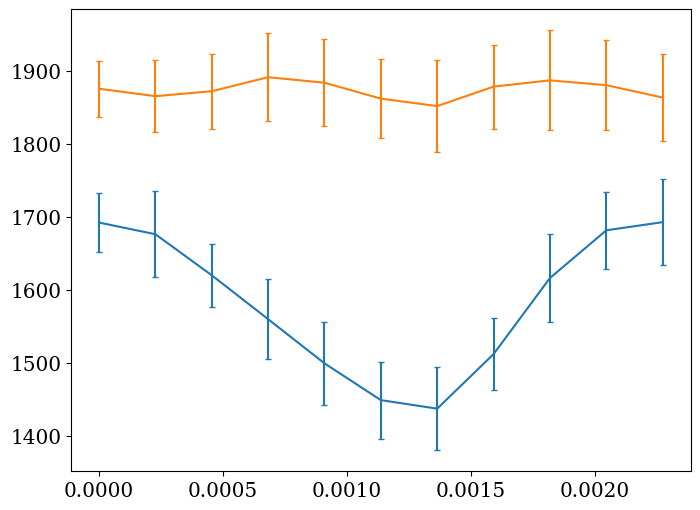

In [4]:
#for i in range(len(freq_offsets)):
    #plt.scatter([freq_offsets[i]]*len(nopad_lls_indiv[i]), nopad_lls_indiv[i])
    #plt.scatter([freq_offsets[i]]*len(pad_lls_indiv[i]), pad_lls_indiv[i], marker='*')
    
plt.errorbar(freq_offsets,nopad_lls, nopad_lls_stds, capsize=2) 
plt.errorbar(freq_offsets,pad_lls, pad_lls_stds, capsize=2) 